In [3]:
! pip install requests pathlib scanpy pandas numpy squidpy

In [4]:
# -- Imports
import os
import requests
import gzip
import shutil
from pathlib import Path
import scanpy as sc
import pandas as pd
import numpy as np
import json
from PIL import Image
import squidpy as sq

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [25]:
# -- Paths
output_raw = "/content/drive/MyDrive/endo-immune-atlas/data/raw/"

output_path_data = "/content/drive/MyDrive/endo-immune-atlas/data/processed"

os.makedirs(output_raw, exist_ok=True)
os.makedirs(output_path_data, exist_ok=True)

In [7]:
# -- DOWNLOAD FILES

GSM6690475_files = [
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_barcodes.tsv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_features.tsv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_matrix.mtx.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_scalefactors_json.json.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_tissue_hires_image.png.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_BEME_346_tissue_positions_list.csv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690475/suppl/GSM6690475_D_V11F09-023_BEME346.tif.gz"]


GSM6690476_files = [
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME_355G_barcodes.tsv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME_355G_features.tsv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME_355G_matrix.mtx.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME-355G_scalefactors_json.json.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME-355G_tissue_hires_image.png.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_BEME-355G_tissue_positions_list.csv.gz",
    "https://ftp.ncbi.nlm.nih.gov/geo/samples/GSM6690nnn/GSM6690476/suppl/GSM6690476_C_V11F09-023_BEME355G.tif.gz"
]

sample_files = {
    "GSM6690475": GSM6690475_files,
    "GSM6690476": GSM6690476_files,
}

for sample, files in sample_files.items():

    sample_dir = os.path.join(output_raw, sample)
    os.makedirs(sample_dir, exist_ok=True)

    print(f"\nDownloading files for {sample}")

    for url in files:
        filename = os.path.join(sample_dir, os.path.basename(url))

        if os.path.exists(filename):
            print(f"Skipping {filename}")
            continue

        print(f"Downloading {filename}")

        r = requests.get(url, stream=True)
        r.raise_for_status()

        with open(filename, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)


Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475/GSM6690475_BEME_346_scalefactors_json.json.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475/GSM6690475_BEME_346_tissue_hires_image.png.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475/GSM6690475_BEME_346_tissue_positions_list.csv.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475/GSM6690475_D_V11F09-023_BEME346.tif.gz

Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476/GSM6690476_BEME-355G_scalefactors_json.json.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476/GSM6690476_BEME-355G_tissue_hires_image.png.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476/GSM6690476_BEME-355G_tissue_positions_list.csv.gz
Skipping /content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476/GSM6690476_C_V11F09-023_BEME355G.tif.gz


In [8]:
# -- BUILD VISIUM STRUCTURE
def build_visium_structure(gsm_dir):
  gsm_dir = Path(gsm_dir)

  matrix_dir = gsm_dir / "filtered_feature_bc_matrix"
  spatial_dir = gsm_dir / "spatial"

  matrix_dir.mkdir(exist_ok=True)
  spatial_dir.mkdir(exist_ok=True)

  matrix_patterns = {
      "*barcodes.tsv.gz": matrix_dir / "barcodes.tsv.gz",
      "*features.tsv.gz": matrix_dir / "features.tsv.gz",
      "*matrix.mtx.gz": matrix_dir / "matrix.mtx.gz"
      }

  spatial_patterns = {
      "*scalefactors_json.json.gz": spatial_dir / "scalefactors_json.json",
      "*tissue_hires_image.png.gz": spatial_dir / "tissue_hires_image.png",
      "*tissue_positions_list.csv.gz": spatial_dir / "tissue_positions_list.csv"
      }

  for pattern, destination in matrix_patterns.items():
    matches = list(gsm_dir.glob(pattern))

    if not matches:
      print(f"Missing: {pattern}")
      continue

    if matches:
      shutil.move(matches[0], destination)

  for pattern, destination in spatial_patterns.items():
    matches = list(gsm_dir.glob(pattern))

    if matches:
      with gzip.open(matches[0], "rb") as f_in:
        with open(destination, "wb") as f_out:
          shutil.copyfileobj(f_in, f_out)


In [9]:
build_visium_structure(
    "/content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475"
)

build_visium_structure(
    "/content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476"
)

Missing: *barcodes.tsv.gz
Missing: *features.tsv.gz
Missing: *matrix.mtx.gz
Missing: *barcodes.tsv.gz
Missing: *features.tsv.gz
Missing: *matrix.mtx.gz


In [10]:
# -- LOAD VIZIUM SAMPLES

def load_visium_sample(gsm_dir, library_id):
  gsm_dir = Path(gsm_dir)

  # - counts
  adata = sc.read_10x_mtx(
      gsm_dir / "filtered_feature_bc_matrix",
      var_names="gene_symbols",
      make_unique=True
  )

  # - coords
  coords = pd.read_csv(
      gsm_dir / "spatial" / "tissue_positions_list.csv",
      header=None
  )

  coords.columns = [
      "barcode",
      "in_tissue",
      "array_row",
      "array_col",
      "pxl_row",
      "pxl_col"
  ]

  coords = coords.set_index("barcode")

  # - map to object

  coords = coords.loc[adata.obs_names]

  adata.obs["in_tissue"] = coords["in_tissue"].values
  adata.obs["array_row"] = coords["array_row"].values
  adata.obs["array_col"] = coords["array_col"].values

  adata.obsm["spatial"] = coords[["pxl_col", "pxl_row"]].values

  # - scale factors
  with open(gsm_dir / "spatial" / "scalefactors_json.json") as f:
    scalefactors = json.load(f)


  # - histology
  hires_img = np.array(
      Image.open(
          gsm_dir / "spatial" / "tissue_hires_image.png"
      )
  )

  # metadata
  adata.uns["spatial"] = {
      library_id: {
      "images": {
          "hires":hires_img
      },
      "scalefactors": scalefactors,
      "metadata": {}
  }
}

  return adata

adata_346 = load_visium_sample(
    "/content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690475",
    "BEME_346"
)

adata_355G = load_visium_sample(
    "/content/drive/MyDrive/endo-immune-atlas/data/raw/GSM6690476",
    "BEME_355G"
)

In [21]:
# -- VALIDATE DATA LOADED CORRECTLY

def data_upload_check(adata):
  print(adata)
  print(f"The shape of data is: {adata.obsm["spatial"].shape}")
  print(f"Tissue Value counts: {adata_346.obs["in_tissue"].value_counts()}")


  overlay_check = sq.pl.spatial_scatter(adata,
                                        color=None
                                        )

  in_tissue_check = sq.pl.spatial_scatter(adata,
                                          color="in_tissue"
                                          )

  return overlay_check, in_tissue_check



AnnData object with n_obs × n_vars = 1388 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types'
    uns: 'spatial'
    obsm: 'spatial'
The shape of data is: (1388, 2)
Tissue Value counts: in_tissue
1    1388
Name: count, dtype: int64


(None, None)

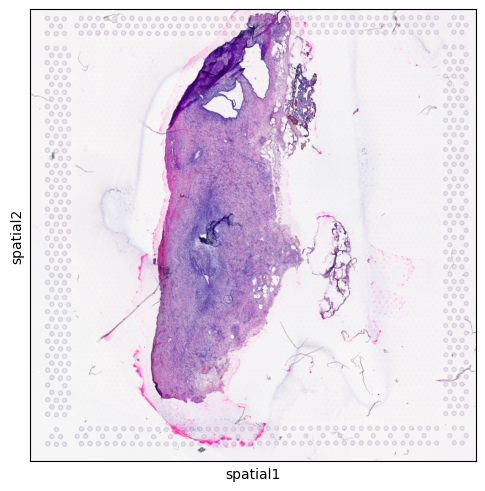

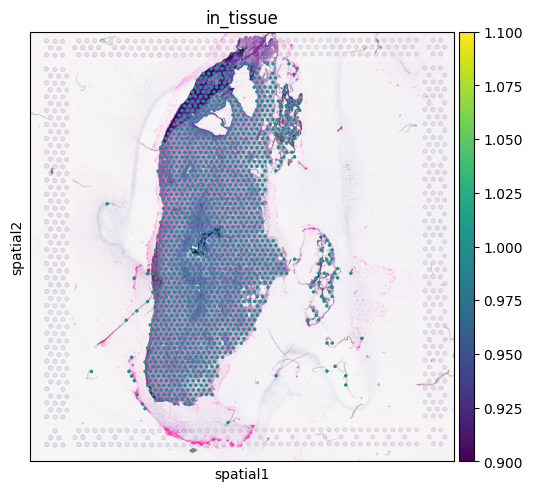

In [22]:
 data_upload_check(adata_346)

In [23]:
# -- Save object for neighborhood analysis

def save_objects(adata, output_path, file_name):
  adata.write_h5ad(os.path.join(output_path, file_name))

In [27]:
save_objects(adata_346, output_path_data, "GSM6690475_BEME_346.h5ad")
save_objects(adata_355G, output_path_data, "GSM6690476_BEME_355G.h5ad")